# Track 2: Financial Inclusion & Poverty Reduction (Rwanda)
**NISR 2026 Big Data Hackathon · Participation Formative · African Leadership University**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IH-honnette/NISR_20226_hackathon/blob/main/Track2_Financial_Inclusion_Poverty.ipynb)

**Team:** Marie Honette IHOZO · Peter Michael Rucakibungo
**Question:** Which households are *both poor and financially excluded*, and can a transparent, leakage-free model flag them well enough to support targeting of financial-inclusion and social-protection programmes?

**Data:** NISR EICV7 (2023/24) cross-sectional microdata, https://statistics.gov.rw (licence: CC BY 4.0). The raw `.dta` files are **not** committed to GitHub; place `Microdata.zip` (or the extracted `Cross_Section/` folder) next to this notebook, or set the environment variable `NISR_DATA_DIR`.

**Status of this notebook (formative):** the whole pipeline runs end-to-end, but the neural network is trained for **`EPOCHS = 1`** only, as the assignment asks. TensorBoard logs (scalars, model graph, histograms, hyper-parameters, test-set curves) are written to `logs/fit/`. View them with `tensorboard --logdir logs/fit`.

**Contents:** 0 Colab / data setup · 1 Setup · 2 Load data · 3 Financial-inclusion indicators · 4 Household features · 5 Merge, target, validation against NISR's published rates · 6 EDA · 7 Features and splits · 8 Baselines and leakage check · 9 Neural network · 10 Train (1 epoch) with TensorBoard · 11 Evaluate and log · 12 Verify logs · 13 Comparison and findings

In [1]:
# ==========================================================================
# SECTION 0 - GOOGLE COLAB / FIRST-RUN DATA SETUP.
# This short cell lets the same notebook run on Google Colab as well as on a laptop. Colab starts with an empty disk, so the EICV7 microdata (Microdata.zip, downloaded from the NISR website) must be supplied first. When the cell detects Colab and cannot find the data, it opens an upload dialog; alternatively mount Google Drive and copy the zip into /content. On a local computer the cell does nothing except print where the data should be placed. Nothing is downloaded from the internet automatically, and the raw survey files are never committed to GitHub, so every user supplies their own copy of the NISR data.
# ==========================================================================
import os, sys

IN_COLAB = "google.colab" in sys.modules


def data_present():
    """True if the EICV7 folder, the zip file, or NISR_DATA_DIR is available."""
    folders = ["Microdata/Cross_Section", "Cross_Section", "/content/Microdata/Cross_Section", "/content/Cross_Section"]
    return (any(os.path.isfile(os.path.join(f, "CS_EICV7_poverty_file.dta")) for f in folders)
            or os.path.isfile("Microdata.zip") or os.path.isfile("/content/Microdata.zip")
            or bool(os.environ.get("NISR_DATA_DIR")))


if IN_COLAB and not data_present():
    from google.colab import files
    print("Upload Microdata.zip (about 43 MB) from your computer ...")
    uploaded = files.upload()
    print("Uploaded:", list(uploaded))
elif IN_COLAB:
    print("Microdata found - continuing.")
else:
    print("Running locally. Put Microdata.zip next to this notebook (or set NISR_DATA_DIR).")

Running locally. Put Microdata.zip next to this notebook (or set NISR_DATA_DIR).


In [2]:
# ==========================================================================
# SECTION 1 - SETUP, CONFIGURATION AND REPRODUCIBILITY.
# This cell imports every library used later, fixes the random seeds so results can be reproduced, and defines the few global settings (number of epochs, batch size, colours, folders). EPOCHS is deliberately 1 because this formative only needs to prove the pipeline runs end-to-end and logs to TensorBoard; raise it for the real competition run. The function find_data_dir() searches the usual places for the EICV7 Cross_Section folder (local, Colab, or an environment variable) and unzips Microdata.zip when necessary, so the same notebook works on any laptop without editing paths. It stops with a clear message if data cannot be found.
# ==========================================================================
import os, glob, zipfile, json, datetime, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve, precision_recall_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorboard.plugins.hparams import api as hp

warnings.filterwarnings("ignore")
SEED = 42
EPOCHS = 1            # placeholder run required by the formative; increase for full training
BATCH_SIZE = 128
OUT_DIR = "outputs"
LOG_ROOT = os.path.join("logs", "fit")
os.makedirs(OUT_DIR, exist_ok=True)
keras.utils.set_random_seed(SEED)

# colours: first three slots of a colour-blind-checked categorical palette
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a85"
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False,
                                     "figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 11})
RESULTS = {}          # collected numbers, saved to outputs/results_summary.json at the end


def find_data_dir():
    """Return the folder that contains CS_EICV7_poverty_file.dta (unzips Microdata.zip if needed)."""
    marker = "CS_EICV7_poverty_file.dta"
    candidates = [os.environ.get("NISR_DATA_DIR", ""), "Microdata/Cross_Section", "Cross_Section",
                  "../Microdata/Cross_Section", "/content/Microdata/Cross_Section", "/content/Cross_Section"]
    for c in candidates:
        if c and os.path.isfile(os.path.join(c, marker)):
            return c
    for z in ["Microdata.zip", "/content/Microdata.zip"]:
        if os.path.isfile(z):
            with zipfile.ZipFile(z) as f:
                f.extractall("Microdata_unzipped")
            hits = glob.glob(os.path.join("Microdata_unzipped", "**", marker), recursive=True)
            if hits:
                return os.path.dirname(hits[0])
    raise FileNotFoundError("EICV7 data not found. Put Microdata.zip next to this notebook or set NISR_DATA_DIR.")


DATA_DIR = find_data_dir()
print("TensorFlow", tf.__version__, "| data folder:", DATA_DIR)

I0000 00:00:1791496450.138807     286 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791496467.108530     286 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791496473.891029     286 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | data folder: Microdata/Cross_Section


In [3]:
# ==========================================================================
# SECTION 2 - LOAD THE EICV7 FILES WE NEED.
# EICV7 is the NISR household survey for 2023/24. Instead of reading every wide file in full, the helper read_dta() loads only the named columns, which keeps memory low and documents exactly which survey questions we rely on. The poverty file is household level (one row per household, with consumption-based poverty status and two weights). The housing, person, savings, credit and VUP files are lower level and are aggregated to households in the next sections. All files share the household identifier hhid, so they can be linked without ambiguity. Row counts are printed so you can confirm the load worked.
# ==========================================================================
def read_dta(name, columns=None):
    """Read a Stata file from DATA_DIR, keeping only the requested columns."""
    return pd.read_stata(os.path.join(DATA_DIR, name), columns=columns)


poverty = read_dta("CS_EICV7_poverty_file.dta",
                   ["hhid", "clust", "province", "district", "ur", "member", "weight", "pop_wt",
                    "quintile", "poverty", "cons1ae"])
housing = read_dta("CS_S01_S5_S7_Household.dta", ["hhid", "s5aq2", "s5aq7", "s5cq14", "s5cq20a"])
person = read_dta("CS_S0_S1_S2_S3_S4_S6A_S6B_S6C_Person.dta",
                  ["hhid", "s1q1", "s1q2", "s1q3y", "s1q4", "s4aq1", "s4aq3"])
savings = read_dta("CS_S10C_Savings.dta", ["hhid", "s10cq4", "s10cq5", "s10cq8"])
credits = read_dta("CS_S10A1_A2_credits.dta", ["hhid", "s10aq1", "s10aq2", "s10aq3"])
vup_fin = read_dta("CS_S9D5_Financial_Services.dta", ["hhid", "s9d5q1"])
vup_ds = read_dta("CS_S9D1_Direct_Support.dta", ["hhid", "s9d1q2"])
vup_cpw = read_dta("CS_S9D2_Classic_Public_Work.dta", ["hhid", "s9d2q1"])
vup_epw = read_dta("CS_S9D3_Expanded_Public_Work.dta", ["hhid", "s9d3q1"])
nsds = read_dta("CS_S9D4_NSDS.dta", ["hhid", "s9d4q1"])

for name, frame in [("poverty (household)", poverty), ("housing (household)", housing), ("person", person),
                    ("savings (account rows)", savings), ("credits (person rows)", credits),
                    ("VUP financial services", vup_fin), ("VUP direct support", vup_ds),
                    ("VUP classic public works", vup_cpw), ("VUP expanded public works", vup_epw),
                    ("Nutrition-sensitive direct support", nsds)]:
    print(f"{name:28s} rows={len(frame):>6,}  households={frame['hhid'].nunique():>6,}")

poverty (household)          rows=15,054  households=15,054
housing (household)          rows=15,054  households=15,054
person                       rows=62,110  households=15,054
savings (account rows)       rows=43,810  households=15,054
credits (person rows)        rows=20,509  households=15,054
VUP financial services       rows=15,054  households=15,054
VUP direct support           rows=15,056  households=15,054
VUP classic public works     rows=15,054  households=15,054
VUP expanded public works    rows=15,055  households=15,054
Nutrition-sensitive direct support rows=15,057  households=15,054


In [4]:
# ==========================================================================
# SECTION 3 - FINANCIAL-INCLUSION INDICATORS (HOUSEHOLD LEVEL).
# Savings rows describe accounts and credit rows describe people, so each file is collapsed to one row per household with simple yes/no flags: any account, a digital account (Momo or Mokash), a SACCO or microfinance account, a bank account, tontine participation, number of accounts, a credit-seeking flag, and whether the household owes money. A small helper, to_flag(), converts Yes/No survey answers once instead of repeating the logic. We also check that the original notebook's two loan flags were the same variable (every household that tried to borrow has a recorded denial reason), so they are merged into one honest indicator. VUP flags are built for coverage analysis only.
# ==========================================================================
def to_flag(series, positive="Yes"):
    """Convert a Yes/No survey answer to 1/0 (missing -> 0)."""
    return (series.astype(str).str.strip() == positive).astype(int)


def contains_flag(series, pattern):
    """1 if the text contains the pattern (case-insensitive), else 0 (missing -> 0)."""
    return series.astype(str).str.contains(pattern, case=False, regex=True, na=False).astype(int)


def clean_cat(series, missing="Unknown"):
    """Text version of a categorical column with missing values labelled explicitly."""
    return series.astype(object).where(series.notna(), missing).astype(str).str.strip()


# --- accounts: one row per account -> one row per household ---
sav = savings.copy()
sav["has_account"] = to_flag(sav["s10cq4"])
sav["digital"] = sav["has_account"] * contains_flag(sav["s10cq5"], "Momo|Mokash")
sav["sacco_mfi"] = sav["has_account"] * contains_flag(sav["s10cq5"], "SACCO|Microfinance")
sav["bank"] = sav["has_account"] * contains_flag(sav["s10cq5"], "Commercial Bank|Cooperative Bank")
sav["tontine"] = to_flag(sav["s10cq8"])
fin_hh = sav.groupby("hhid").agg(hh_has_account=("has_account", "max"), hh_uses_digital=("digital", "max"),
                                 hh_has_sacco_mfi=("sacco_mfi", "max"), hh_has_bank=("bank", "max"),
                                 hh_in_tontine=("tontine", "max"), n_accounts=("has_account", "sum")).reset_index()

# --- credit: s10aq1 = tried to obtain a loan; s10aq2 = reason it was denied; s10aq3 = owes money ---
cr = credits.copy()
cr["tried"] = to_flag(cr["s10aq1"])
cr["owes"] = to_flag(cr["s10aq3"])
same = bool((cr["tried"] == cr["s10aq2"].notna().astype(int)).all())
print("'Tried to get a loan' and 'denial reason recorded' are identical:", same)
credit_hh = cr.groupby("hhid").agg(hh_credit_constrained=("tried", "max"), hh_owes_money=("owes", "max")).reset_index()

def household_flag(frame, column, name):
    """One row per household: 1 if any row answers Yes in `column`."""
    return frame.assign(**{name: to_flag(frame[column])}).groupby("hhid")[name].max().reset_index()


# --- social-protection participation (used for coverage analysis, NOT as model inputs) ---
programmes = [(vup_ds, "s9d1q2", "hh_vup_ds"), (vup_cpw, "s9d2q1", "hh_vup_cpw"), (vup_epw, "s9d3q1", "hh_vup_epw"),
              (nsds, "s9d4q1", "hh_nsds"), (vup_fin, "s9d5q1", "hh_vup_fin_applied")]
vup_hh = None
for frame, column, name in programmes:
    piece = household_flag(frame, column, name)
    vup_hh = piece if vup_hh is None else vup_hh.merge(piece, on="hhid", how="outer")
print(fin_hh.shape, credit_hh.shape, vup_hh.shape)
fin_hh.describe().T[["mean", "max"]].round(3)

'Tried to get a loan' and 'denial reason recorded' are identical: True
(15054, 7) (15054, 3) (15054, 6)


,mean,max
hhid,307527.469,315054.0
hh_has_account,0.886,1.0
hh_uses_digital,0.796,1.0
hh_has_sacco_mfi,0.496,1.0
hh_has_bank,0.226,1.0
hh_in_tontine,0.740,1.0
n_accounts,2.598,24.0


In [5]:
# ==========================================================================
# SECTION 4 - HOUSEHOLD AND HOUSEHOLD-HEAD CHARACTERISTICS.
# Here we build the socio-economic part of the feature set, deliberately limited to things a field officer could observe or ask without measuring consumption: dwelling type and ownership, grid electricity, internet at home, the head's sex, age, marital status and education, household size, and the number of children under 15 and adults aged 65 or more. Using only observable proxies matters because the long-term goal is a proxy-means style tool for targeting. Consumption, consumption quintile and the official poverty indicators are not used as inputs because they define the target and would leak the answer. Missing categories are labelled Unknown rather than dropped.
# ==========================================================================
person = person.copy()
person["age"] = pd.to_numeric(person["s1q3y"], errors="coerce")
person["child"] = (person["age"] < 15).astype(int)
person["elder"] = (person["age"] >= 65).astype(int)
structure = person.groupby("hhid").agg(n_children=("child", "sum"), n_elderly=("elder", "sum")).reset_index()

head = person[person["s1q2"].astype(str).str.contains("head", case=False)].drop_duplicates("hhid").copy()
head["head_education"] = clean_cat(head["s4aq3"])
head.loc[head["s4aq1"].astype(str).str.strip() == "No", "head_education"] = "Never schooled"
head = head.rename(columns={"s1q1": "head_sex", "age": "head_age", "s1q4": "head_marital_status"})
head = head[["hhid", "head_sex", "head_age", "head_marital_status", "head_education"]]

housing_feats = housing.rename(columns={"s5aq2": "dwelling_type", "s5aq7": "dwelling_owner",
                                        "s5cq14": "has_electricity", "s5cq20a": "has_internet"})
print("Household heads found:", len(head), "of", poverty["hhid"].nunique(), "households")
print("Head education categories:", sorted(head["head_education"].unique())[:8], "...")

Household heads found: 15054 of 15054 households
Head education categories: ['A2/D6/D7', 'A3/D4/D5', 'Bachelor(A0): D6+3-6yrs', 'Diploma(A1): D6+2-3yrs', 'Doctorate(PhD)', 'EMA/ENTA', 'Masters: Bachelor+1-2yrs', 'Never schooled'] ...


In [6]:
# ==========================================================================
# SECTION 5 - MERGE, TARGET DEFINITION AND VALIDATION AGAINST NISR'S PUBLISHED RATES.
# All pieces are merged on hhid into one analytical table with one row per household. Missing financial or programme flags mean the household has no record in that module, so they are set to 0, and missing categories become Unknown. The target is_poor equals 1 when the official welfare category is not Non Poor; is_extreme equals 1 for the severely poor. Poverty is a statement about people, so rates must use the population weight pop_wt, not an unweighted household count. As a sanity check we reproduce NISR's published EICV7 headline rates of 27.4 percent poor and 5.4 percent extremely poor; matching them confirms the data and weights are used correctly.
# ==========================================================================
df = poverty.copy()
for piece in [housing_feats, head, structure, fin_hh, credit_hh, vup_hh]:
    df = df.merge(piece, on="hhid", how="left")

flag_cols = ["hh_has_account", "hh_uses_digital", "hh_has_sacco_mfi", "hh_has_bank", "hh_in_tontine", "n_accounts",
             "hh_credit_constrained", "hh_owes_money", "hh_vup_fin_applied", "hh_vup_ds", "hh_vup_cpw", "hh_vup_epw", "hh_nsds"]
df[flag_cols] = df[flag_cols].fillna(0).astype(int)
SP_COLS = ["hh_vup_ds", "hh_vup_cpw", "hh_vup_epw", "hh_nsds"]          # cash / work / nutrition support
df["hh_any_sp"] = df[SP_COLS].max(axis=1)
df["hh_size"] = df["member"].astype(float)
for c in ["dwelling_type", "dwelling_owner", "has_electricity", "has_internet", "head_sex",
          "head_marital_status", "head_education", "province", "ur", "quintile", "poverty"]:
    df[c] = clean_cat(df[c])
df["head_age"] = pd.to_numeric(df["head_age"], errors="coerce")
df["head_age"] = df["head_age"].fillna(df["head_age"].median())
df[["n_children", "n_elderly"]] = df[["n_children", "n_elderly"]].fillna(0)

df["is_poor"] = (df["poverty"] != "Non Poor").astype(int)
df["is_extreme"] = df["poverty"].str.contains("Sever", case=False).astype(int)
assert df["hhid"].is_unique and len(df) == len(poverty)

OFFICIAL = {"poor": 27.4, "extreme": 5.4}        # NISR EICV7 press release (2024)
ours = {"poor": 100 * np.average(df["is_poor"], weights=df["pop_wt"]),
        "extreme": 100 * np.average(df["is_extreme"], weights=df["pop_wt"])}
naive = 100 * df["is_poor"].mean()
print(f"Poverty rate  - ours (pop_wt): {ours['poor']:.1f}% | NISR published: {OFFICIAL['poor']}% | unweighted household share: {naive:.1f}%")
print(f"Extreme rate  - ours (pop_wt): {ours['extreme']:.1f}% | NISR published: {OFFICIAL['extreme']}%")
RESULTS["n_households"] = int(len(df))
RESULTS["poverty_rate_popwt"] = round(ours["poor"], 2)
RESULTS["extreme_rate_popwt"] = round(ours["extreme"], 2)
RESULTS["poverty_rate_unweighted"] = round(naive, 2)
RESULTS["n_poor_households"] = int(df["is_poor"].sum())
RESULTS["n_extreme_households"] = int(df["is_extreme"].sum())

Poverty rate  - ours (pop_wt): 27.4% | NISR published: 27.4% | unweighted household share: 23.8%
Extreme rate  - ours (pop_wt): 5.4% | NISR published: 5.4%


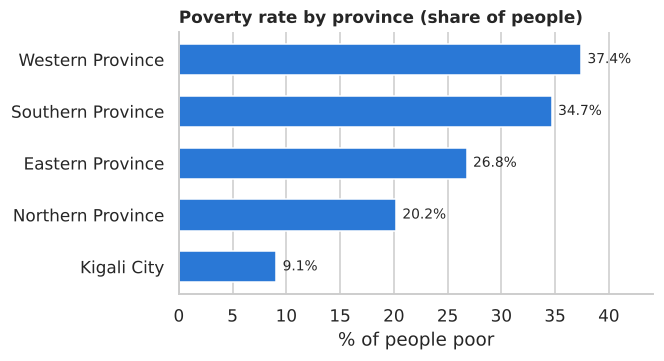

,share of households with it,poverty rate | yes,poverty rate | no
indicator,,,
Any bank / mobile-money account,88.8,25.6,46.5
Mobile-money (Momo/Mokash) account,80.3,24.3,43.5
SACCO / microfinance account,47.7,24.7,30.2
Commercial / cooperative bank,23.8,8.1,33.9
Tontine / savings group,73.1,26.4,30.7
Tried to borrow (denial recorded),5.5,30.8,27.2
Currently owes money,67.9,27.1,28.1


,VUP Direct Support (cash),Classic Public Works,Expanded Public Works,Nutrition-sensitive Direct Support,Any of the four programmes
Non-poor,2.4,1.8,1.7,2.9,8.6
Moderately poor,3.7,3.9,3.1,4.4,14.2
Extremely poor,3.5,6.5,3.5,4.9,17.2


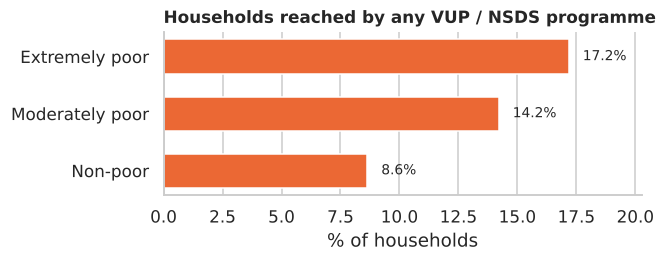

{'Poor': 0.808, 'Poor/mid': 0.857, 'Mid': 0.878, 'Mid/upper': 0.909, 'Upper': 0.96}


In [7]:
# ==========================================================================
# SECTION 6 - EXPLORATORY ANALYSIS: WHO IS POOR, WHO IS EXCLUDED, WHO IS REACHED?
# Three questions are answered with weighted statistics. First, how does poverty differ between rural and urban areas and across provinces? Second, how do poverty rates differ for households with and without each financial-inclusion indicator? Third, how well does VUP Direct Support reach the poor? The helper weighted_rate_by() is reused for every table so weighting is applied consistently: pop_wt for poverty headcounts (people), and the household weight for coverage shares (households). Figures are saved into outputs/ so they can be dropped into the proposal. Consumption quintile appears here only for description, never as a model input.
# ==========================================================================
def weighted_rate_by(frame, by, outcome, wcol):
    """Weighted mean of a 0/1 outcome inside each group of `by`."""
    return pd.Series({k: np.average(g[outcome], weights=g[wcol]) for k, g in frame.groupby(by, observed=True)})


def bar_h(series, title, xlabel, color=BLUE, fname=None, pct=True):
    """Horizontal bar chart with direct value labels; saved to OUT_DIR when fname is given."""
    s = series.sort_values()
    fig, ax = plt.subplots(figsize=(6.2, 0.45 * len(s) + 1.2))
    ax.barh(s.index.astype(str), 100 * s.values if pct else s.values, color=color, height=0.6)
    for i, v in enumerate(100 * s.values if pct else s.values):
        ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=9)
    ax.set_title(title, loc="left"); ax.set_xlabel(xlabel); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, (100 * s.max() if pct else s.max()) * 1.18)
    plt.tight_layout()
    if fname:
        fig.savefig(os.path.join(OUT_DIR, fname), dpi=200, bbox_inches="tight")
    plt.show()


# 1) poverty by residence and province (share of people, pop_wt)
by_ur = weighted_rate_by(df, "ur", "is_poor", "pop_wt")
by_prov = weighted_rate_by(df, "province", "is_poor", "pop_wt")
bar_h(by_prov, "Poverty rate by province (share of people)", "% of people poor", BLUE, "fig_poverty_province.png")
RESULTS["poverty_by_ur"] = {k: round(100 * v, 1) for k, v in by_ur.items()}
RESULTS["poverty_by_province"] = {k: round(100 * v, 1) for k, v in by_prov.items()}

# 2) poverty by financial-inclusion status
FIN_LABELS = {"hh_has_account": "Any bank / mobile-money account", "hh_uses_digital": "Mobile-money (Momo/Mokash) account",
              "hh_has_sacco_mfi": "SACCO / microfinance account", "hh_has_bank": "Commercial / cooperative bank",
              "hh_in_tontine": "Tontine / savings group", "hh_credit_constrained": "Tried to borrow (denial recorded)",
              "hh_owes_money": "Currently owes money"}
rows = []
for col, label in FIN_LABELS.items():
    rows.append({"indicator": label,
                 "share of households with it": np.average(df[col], weights=df["weight"]),
                 "poverty rate | yes": np.average(df.loc[df[col] == 1, "is_poor"], weights=df.loc[df[col] == 1, "pop_wt"]),
                 "poverty rate | no": np.average(df.loc[df[col] == 0, "is_poor"], weights=df.loc[df[col] == 0, "pop_wt"])})
fin_table = pd.DataFrame(rows).set_index("indicator")
RESULTS["fin_table"] = {k: {c: round(float(v), 3) for c, v in r.items()} for k, r in fin_table.iterrows()}
display((fin_table * 100).round(1))

# 3) social-protection coverage by poverty status (households, household weight)
SP_LABELS = {"hh_vup_ds": "VUP Direct Support (cash)", "hh_vup_cpw": "Classic Public Works", "hh_vup_epw": "Expanded Public Works",
             "hh_nsds": "Nutrition-sensitive Direct Support", "hh_any_sp": "Any of the four programmes"}
labels = {"Non Poor": "Non-poor", "Moderately poor": "Moderately poor", "Severaly Poor": "Extremely poor"}
sp_cov = pd.DataFrame({lab: weighted_rate_by(df, "poverty", col, "weight") for col, lab in SP_LABELS.items()})
sp_cov = sp_cov.rename(index=labels).reindex(list(labels.values()))
display((sp_cov * 100).round(1))
bar_h(sp_cov["Any of the four programmes"], "Households reached by any VUP / NSDS programme", "% of households",
      ORANGE, "fig_sp_coverage.png")
RESULTS["sp_coverage"] = {g: {c: round(100 * float(v), 1) for c, v in row.items()} for g, row in sp_cov.iterrows()}
RESULTS["vup_ds_coverage"] = {g: RESULTS["sp_coverage"][g]["VUP Direct Support (cash)"] for g in sp_cov.index}

# 4) account ownership by consumption quintile (description only)
order = ["Poor", "Poor/mid", "Mid", "Mid/upper", "Upper"]
acc_q = weighted_rate_by(df, "quintile", "hh_has_account", "weight").reindex(order)
RESULTS["account_by_quintile"] = {k: round(100 * v, 1) for k, v in acc_q.items()}
print(acc_q.round(3).to_dict())

In [8]:
# ==========================================================================
# SECTION 7 - FEATURE SETS AND CLUSTER-AWARE TRAIN / VALIDATION / TEST SPLIT.
# Features are split into categorical socio-economic variables, numeric socio-economic variables and financial-inclusion variables. A guard asserts that no leaking column (consumption, quintile, official poverty fields) and no programme-participation flag enters the inputs. Households interviewed in the same survey cluster resemble each other, so a random row split would let near-duplicates appear in both training and test data and inflate scores; we therefore split by cluster with GroupShuffleSplit (64 percent train, 16 percent validation, 20 percent test). The same split feeds all models. Tabular models get one-hot inputs; the neural network gets integer codes for embeddings plus standardised numbers.
# ==========================================================================
CAT = ["province", "ur", "dwelling_type", "dwelling_owner", "has_electricity", "has_internet",
       "head_sex", "head_marital_status", "head_education"]
NUM_SOCIO = ["head_age", "hh_size", "n_children", "n_elderly"]
FIN = ["hh_has_account", "hh_uses_digital", "hh_has_sacco_mfi", "hh_has_bank", "hh_in_tontine", "n_accounts",
       "hh_credit_constrained", "hh_owes_money"]
FORBIDDEN = {"quintile", "cons1ae", "poverty", "is_poor", "is_extreme", "hh_vup_fin_applied", "hh_any_sp"} | set(SP_COLS)
assert not (set(CAT + NUM_SOCIO + FIN) & FORBIDDEN), "a leaking column slipped into the features"


def group_split(frame_index, groups, test_size, seed):
    """Split positions so that whole survey clusters stay together."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(gss.split(frame_index, groups=groups))
    return a, b


all_idx = np.arange(len(df))
trv, test_idx = group_split(all_idx, df["clust"].values, 0.20, SEED)
tr_rel, val_rel = group_split(trv, df["clust"].values[trv], 0.20, SEED + 1)
train_idx, val_idx = trv[tr_rel], trv[val_rel]
assert not set(df["clust"].iloc[train_idx]) & set(df["clust"].iloc[test_idx]), "cluster leakage"
y_all, y_ext_all = df["is_poor"].values, df["is_extreme"].values
print(f"train={len(train_idx):,} val={len(val_idx):,} test={len(test_idx):,} | poor share train={y_all[train_idx].mean():.3f} test={y_all[test_idx].mean():.3f}")

# one-hot matrix for LR / RF (numeric columns standardised on the training rows only)
onehot = pd.get_dummies(df[CAT], dtype=float)
num_cols = NUM_SOCIO + FIN
X_tab = pd.concat([onehot, df[num_cols].astype(float)], axis=1)
scaler_tab = StandardScaler().fit(X_tab.iloc[train_idx])
X_tab_scaled = pd.DataFrame(scaler_tab.transform(X_tab), columns=X_tab.columns, index=X_tab.index)
FEATURE_GROUPS = {c: [k for k in X_tab.columns if k.startswith(c + "_")] for c in CAT}
FEATURE_GROUPS.update({c: [c] for c in num_cols})
RESULTS["n_features_tabular"] = int(X_tab.shape[1])

train=9,634 val=2,409 test=3,011 | poor share train=0.238 test=0.240


In [9]:
# ==========================================================================
# SECTION 8 - BASELINE MODELS, ABLATION AND A LEAKAGE CHECK.
# Before any deep learning we need honest benchmarks. Logistic regression is the transparent, linear baseline; a random forest captures non-linear interactions and is usually very strong on tabular survey data. The helper evaluate_binary() reports ROC-AUC, average precision, accuracy, precision, recall and F1 for the poor class, plus a population-weighted AUC, and is reused for every model. Two extra experiments support the argument: an ablation that removes the financial-inclusion variables to see how much they add beyond housing and demographics, and a leakage check that adds the consumption quintile to show how misleadingly high scores become when the target is leaked.
# ==========================================================================
def evaluate_binary(name, y_true, proba, weights=None, threshold=0.5):
    """Return a dict of discrimination and classification metrics for the positive (poor) class."""
    pred = (proba >= threshold).astype(int)
    return {"model": name, "roc_auc": roc_auc_score(y_true, proba), "avg_precision": average_precision_score(y_true, proba),
            "roc_auc_popweighted": roc_auc_score(y_true, proba, sample_weight=weights),
            "accuracy": accuracy_score(y_true, pred), "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred), "f1": f1_score(y_true, pred)}


def fit_lr(cols):
    m = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    m.fit(X_tab_scaled.iloc[train_idx][cols], y_all[train_idx])
    return m, m.predict_proba(X_tab_scaled.iloc[test_idx][cols])[:, 1]


def fit_rf(cols):
    m = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5, class_weight="balanced",
                               random_state=SEED, n_jobs=-1)
    m.fit(X_tab.iloc[train_idx][cols], y_all[train_idx])
    return m, m.predict_proba(X_tab.iloc[test_idx][cols])[:, 1]


y_test, w_test = y_all[test_idx], df["pop_wt"].values[test_idx]
all_cols = list(X_tab.columns)
fin_cols = [c for c in all_cols if c in FIN]
no_fin_cols = [c for c in all_cols if c not in FIN]

lr_model, p_lr = fit_lr(all_cols)
rf_model, p_rf = fit_rf(all_cols)
results = [evaluate_binary("Logistic regression", y_test, p_lr, w_test), evaluate_binary("Random forest", y_test, p_rf, w_test)]

# ablation: remove financial-inclusion variables
_, p_rf_nofin = fit_rf(no_fin_cols)
_, p_lr_nofin = fit_lr(no_fin_cols)
RESULTS["ablation"] = {"rf_auc_with_fin": round(roc_auc_score(y_test, p_rf), 4), "rf_auc_without_fin": round(roc_auc_score(y_test, p_rf_nofin), 4),
                       "lr_auc_with_fin": round(roc_auc_score(y_test, p_lr), 4), "lr_auc_without_fin": round(roc_auc_score(y_test, p_lr_nofin), 4)}

# leakage demonstration: add quintile (derived from the same consumption aggregate that defines poverty)
q = pd.get_dummies(df["quintile"], prefix="LEAK_quintile", dtype=float)
X_leak = pd.concat([X_tab_scaled, q], axis=1)
lr_leak = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED).fit(X_leak.iloc[train_idx], y_all[train_idx])
RESULTS["leakage_lr_auc_with_quintile"] = round(roc_auc_score(y_test, lr_leak.predict_proba(X_leak.iloc[test_idx])[:, 1]), 4)

print(pd.DataFrame(results).round(3).to_string(index=False))
print("Ablation (AUC):", RESULTS["ablation"])
print("Leakage check - logistic regression AUC if quintile is (wrongly) added:", RESULTS["leakage_lr_auc_with_quintile"])

              model  roc_auc  avg_precision  roc_auc_popweighted  accuracy  precision  recall    f1
Logistic regression    0.789          0.539                0.794     0.685      0.415   0.759 0.536
      Random forest    0.776          0.513                0.777     0.672      0.401   0.748 0.522
Ablation (AUC): {'rf_auc_with_fin': 0.7762, 'rf_auc_without_fin': 0.7569, 'lr_auc_with_fin': 0.7895, 'lr_auc_without_fin': 0.7683}
Leakage check - logistic regression AUC if quintile is (wrongly) added: 0.9775


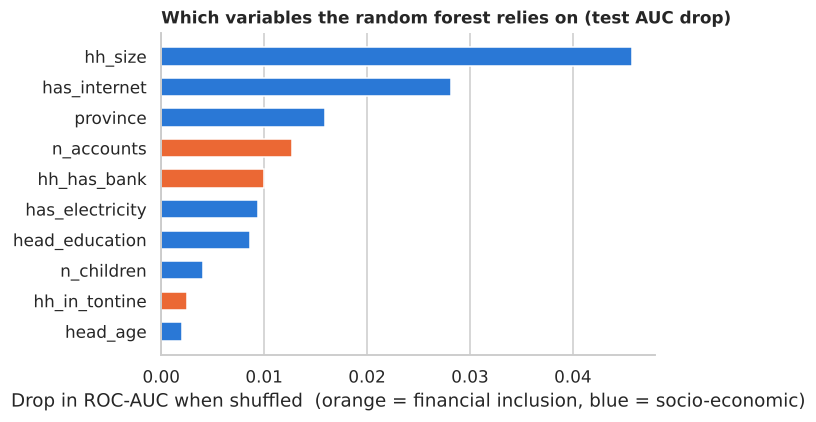

{'hh_size': 0.0457, 'has_internet': 0.0281, 'province': 0.0159, 'n_accounts': 0.0127, 'hh_has_bank': 0.01, 'has_electricity': 0.0094, 'head_education': 0.0086, 'n_children': 0.004}


In [10]:
# ==========================================================================
# SECTION 9 - WHICH FEATURE GROUPS MATTER? (GROUPED PERMUTATION IMPORTANCE).
# Impurity-based importances are biased toward many-level variables and split one-hot dummies into fragments. Instead we shuffle each original variable (all of its dummy columns together) on the held-out test set and measure how much the random forest's ROC-AUC falls; a bigger drop means the model relied on that variable more. Repeating three times averages out luck. The function grouped_permutation_importance() is reusable for any fitted model. The result ranks housing, location, demographics and financial-inclusion variables on one scale, which connects the model back to the policy question of what separates poor from non-poor households.
# ==========================================================================
def grouped_permutation_importance(model, X, y, groups, n_repeats=3, seed=SEED):
    """AUC drop when each feature group (several columns) is shuffled jointly."""
    rng = np.random.default_rng(seed)
    base = roc_auc_score(y, model.predict_proba(X)[:, 1])
    out = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            perm = rng.permutation(len(Xp))
            Xp[cols] = Xp[cols].values[perm]
            drops.append(base - roc_auc_score(y, model.predict_proba(Xp)[:, 1]))
        out[name] = float(np.mean(drops))
    return pd.Series(out).sort_values(ascending=False)


imp = grouped_permutation_importance(rf_model, X_tab.iloc[test_idx], y_test, FEATURE_GROUPS)
top = imp.head(10).sort_values()
fig, ax = plt.subplots(figsize=(6.2, 4))
colors = [ORANGE if k in FIN else BLUE for k in top.index]
ax.barh(top.index, top.values, color=colors, height=0.6)
ax.set_title("Which variables the random forest relies on (test AUC drop)", loc="left")
ax.set_xlabel("Drop in ROC-AUC when shuffled  (orange = financial inclusion, blue = socio-economic)")
ax.grid(axis="y", visible=False); plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_importance.png"), dpi=200, bbox_inches="tight"); plt.show()
RESULTS["top_importance"] = {k: round(v, 4) for k, v in imp.head(8).items()}
RESULTS["fin_importance"] = {k: round(float(imp[k]), 4) for k in FIN}
print(imp.head(8).round(4).to_dict())

## Neural network design (what we build and why)
**Input.** Each categorical variable gets its own learned **embedding** (province, dwelling type, education, …), and the numeric variables are standardised and concatenated with the embeddings. Embeddings let the network learn that, for example, two dwelling types behave similarly without an explicit one-hot blow-up.

**Trunk.** `Dense(64, ReLU) → BatchNorm → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.2)`: small on purpose, because we have only ≈ 15,000 households; BatchNorm stabilises the first epochs and Dropout limits over-fitting.

**Two heads (multi-task).** One sigmoid head predicts *poor*, a second predicts *extremely poor*. Extreme poverty is rare (≈ 4% of households), so on its own it gives a weak training signal; sharing the trunk lets the rarer, more policy-critical label borrow structure from the common one. The auxiliary loss is down-weighted (0.3) so the main task stays dominant.

**Why this and not the alternatives?** A gradient-boosted tree or random forest is the usual favourite for tabular survey data and is our benchmark; we expect it to be competitive, and we report the comparison honestly. We still build the network because (1) embeddings plus a shared multi-task trunk give one model for both the poor and extremely-poor targeting questions, (2) it can be extended later with new modalities such as satellite or mobile-phone features, which trees handle poorly, and (3) it logs rich diagnostics (graph, histograms, hyper-parameters) to TensorBoard. Logistic regression is the interpretable floor.

In [11]:
# ==========================================================================
# SECTION 10 - NEURAL NETWORK INPUTS AND ARCHITECTURE (EMBEDDINGS + SHARED TRUNK + TWO HEADS).
# This cell converts the data into the format the network needs and defines the model. Each categorical column becomes integer codes feeding its own Embedding layer, numeric columns are standardised on training rows only, and the embeddings are concatenated with the numbers. A shared trunk of two dense layers feeds two sigmoid heads: poor and extremely poor. build_model() takes a dictionary of hyper-parameters so exactly the same function can be reused for tuning later, and the same dictionary is logged to TensorBoard's HParams tab. Balanced sample weights counter class imbalance without needing class_weight, which Keras does not support for multi-output models.
# ==========================================================================
HPARAMS = {"embed_dim": 4, "units_1": 64, "units_2": 32, "dropout_1": 0.3, "dropout_2": 0.2,
           "learning_rate": 1e-3, "aux_loss_weight": 0.3, "batch_size": BATCH_SIZE, "epochs": EPOCHS}

cat_codes = {c: (df[c].astype("category").cat.codes.values + 1).astype("int32") for c in CAT}   # 0 reserved for unseen
cat_vocab = {c: int(v.max()) for c, v in cat_codes.items()}
num_cols_nn = NUM_SOCIO + FIN
scaler_nn = StandardScaler().fit(df.iloc[train_idx][num_cols_nn].astype(float))
num_scaled = scaler_nn.transform(df[num_cols_nn].astype(float)).astype("float32")


def make_inputs(idx):
    """Dictionary of model inputs for the given row positions."""
    d = {f"cat_{c}": cat_codes[c][idx].reshape(-1, 1) for c in CAT}
    d["numeric"] = num_scaled[idx]
    return d


def make_targets(idx):
    return {"poor": y_all[idx].astype("float32"), "extreme_poor": y_ext_all[idx].astype("float32")}


def balanced_weights(y):
    """Per-row weights so both classes carry equal total weight."""
    pos = y.mean()
    return np.where(y == 1, 0.5 / pos, 0.5 / (1 - pos)).astype("float32")


def build_model(h):
    inputs, parts = {}, []
    for c, v in cat_vocab.items():
        inp = keras.Input(shape=(1,), dtype="int32", name=f"cat_{c}")
        dim = max(2, min(h["embed_dim"], (v + 1) // 2))
        parts.append(layers.Flatten(name=f"flat_{c}")(layers.Embedding(v + 1, dim, name=f"emb_{c}")(inp)))
        inputs[f"cat_{c}"] = inp
    num_in = keras.Input(shape=(len(num_cols_nn),), name="numeric")
    inputs["numeric"] = num_in
    x = layers.Concatenate(name="concat")(parts + [num_in])
    x = layers.Dense(h["units_1"], activation="relu", name="dense_1")(x)
    x = layers.BatchNormalization(name="batchnorm")(x)
    x = layers.Dropout(h["dropout_1"], name="dropout_1")(x)
    x = layers.Dense(h["units_2"], activation="relu", name="dense_2")(x)
    x = layers.Dropout(h["dropout_2"], name="dropout_2")(x)
    out = {"poor": layers.Dense(1, activation="sigmoid", name="poor")(x),
           "extreme_poor": layers.Dense(1, activation="sigmoid", name="extreme_poor")(x)}
    model = keras.Model(inputs, out, name="poverty_embedding_mtl")
    model.compile(optimizer=keras.optimizers.Adam(h["learning_rate"]),
                  loss={"poor": "binary_crossentropy", "extreme_poor": "binary_crossentropy"},
                  loss_weights={"poor": 1.0, "extreme_poor": h["aux_loss_weight"]},
                  metrics={"poor": ["accuracy", keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")],
                           "extreme_poor": [keras.metrics.AUC(name="auc"), keras.metrics.Recall(name="recall")]})
    return model


model = build_model(HPARAMS)
model.summary(line_length=100)

Model: "poverty_embedding_mtl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ cat_province (InputLayer)   │ (None, 1)               │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_ur (InputLayer)         │ (None, 1)               │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_dwelling_type           │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_dwelling_owner          │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_has_electricity         │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_has_internet            │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_head_sex (InputLayer)   │ (None, 1)               │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_head_marital_status     │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ cat_head_education          │ (None, 1)               │              0 │ -                       │
│ (InputLayer)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ emb_province (Embedding)    │ (None, 1, 3)            │             18 │ cat_province[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ emb_ur (Embedding)          │ (None, 1, 2)            │              6 │ cat_ur[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ emb_dwelling_type           │ (None, 1, 3)            │             21 │ cat_dwelling_type[0][0] │
│ (Embedding)                 │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ emb_dwelling_owner          │ (None, 1, 4)            │             40 │ cat_dwelling_owner[0][… │
│ (Embedding)                 │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ emb_has_electricity         │ (None, 1, 2)            │             10 │ cat_has_electricity[0]… │
│ (Embedding)                 │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 5,109 (19.96 KB)

 Trainable params: 4,981 (19.46 KB)

 Non-trainable params: 128 (512.00 B)

In [12]:
# ==========================================================================
# SECTION 11 - TRAIN FOR ONE EPOCH WITH TENSORBOARD LOGGING.
# This is the placeholder run required by the formative: one pass over the training data is enough to prove the pipeline works from raw data to a trained network, without chasing final accuracy. Each run writes to its own timestamped folder under logs/fit. Two callbacks are attached: the standard TensorBoard callback (loss and metrics per batch and epoch, the model graph and weight histograms) and an HParams callback that records the hyper-parameter dictionary. Validation data comes from clusters not seen in training. To train properly later, change EPOCHS in Section 1 and add early stopping.
# ==========================================================================
run_id = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = os.path.join(LOG_ROOT, run_id)

tb_callback = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True,
                                          update_freq="batch", profile_batch=0)
hp_callback = hp.KerasCallback(log_dir, HPARAMS)

history = model.fit(
    make_inputs(train_idx), make_targets(train_idx),
    sample_weight={"poor": balanced_weights(y_all[train_idx]), "extreme_poor": balanced_weights(y_ext_all[train_idx])},
    validation_data=(make_inputs(val_idx), make_targets(val_idx)),
    epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[tb_callback, hp_callback], verbose=1)

print("\nLogged to:", log_dir)
print("Epoch history keys:", sorted(history.history.keys())[:6], "...")

 1/76 ━━━━━━━━━━━━━━━━━━━━ 4:40 4s/step - extreme_poor_auc: 0.5295 - extreme_poor_loss: 0.9195 - extreme_poor_recall: 0.7143 - loss: 1.1936 - poor_accuracy: 0.3516 - poor_auc: 0.4308 - poor_loss: 0.9178 - poor_recall: 0.6452

10/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.6081 - extreme_poor_loss: 0.7789 - extreme_poor_recall: 0.8261 - loss: 1.0399 - poor_accuracy: 0.4398 - poor_auc: 0.5461 - poor_loss: 0.8062 - poor_recall: 0.7125 

19/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.5935 - extreme_poor_loss: 0.7947 - extreme_poor_recall: 0.7423 - loss: 1.0054 - poor_accuracy: 0.4613 - poor_auc: 0.5759 - poor_loss: 0.7670 - poor_recall: 0.7170

28/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.5977 - extreme_poor_loss: 0.7780 - extreme_poor_recall: 0.7083 - loss: 0.9665 - poor_accuracy: 0.4919 - poor_auc: 0.6077 - poor_loss: 0.7331 - poor_recall: 0.7193

36/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.6170 - extreme_poor_loss: 0.7582 - extreme_poor_recall: 0.7049 - loss: 0.9468 - poor_accuracy: 0.5124 - poor_auc: 0.6195 - poor_loss: 0.7193 - poor_recall: 0.7100

...

53/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.6379 - extreme_poor_loss: 0.7328 - extreme_poor_recall: 0.7048 - loss: 0.9192 - poor_accuracy: 0.5454 - poor_auc: 0.6353 - poor_loss: 0.6993 - poor_recall: 0.6938

62/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.6457 - extreme_poor_loss: 0.7234 - extreme_poor_recall: 0.6944 - loss: 0.9137 - poor_accuracy: 0.5558 - poor_auc: 0.6393 - poor_loss: 0.6966 - poor_recall: 0.6854

71/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - extreme_poor_auc: 0.6504 - extreme_poor_loss: 0.7147 - extreme_poor_recall: 0.6900 - loss: 0.9030 - poor_accuracy: 0.5655 - poor_auc: 0.6455 - poor_loss: 0.6886 - poor_recall: 0.6772

76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - extreme_poor_auc: 0.6500 - extreme_poor_loss: 0.7202 - extreme_poor_recall: 0.6807 - loss: 0.9005 - poor_accuracy: 0.5701 - poor_auc: 0.6507 - poor_loss: 0.6845 - poor_recall: 0.6778 - val_extreme_poor_auc: 0.7666 - val_extreme_poor_loss: 0.6434 - val_extreme_poor_recall: 0.7300 - val_loss: 0.8142 - val_poor_accuracy: 0.6654 - val_poor_auc: 0.7387 - val_poor_loss: 0.6205 - val_poor_recall: 0.6993



Logged to: logs/fit/20261008-235447
Epoch history keys: ['extreme_poor_auc', 'extreme_poor_loss', 'extreme_poor_recall', 'loss', 'poor_accuracy', 'poor_auc'] ...


In [13]:
# ==========================================================================
# SECTION 12 - EVALUATE ON THE HELD-OUT TEST CLUSTERS AND LOG EXTRA DIAGNOSTICS.
# The trained network predicts probabilities for test households, and the same evaluate_binary() used for the baselines scores them, so all models are compared fairly. Beyond the automatic curves we write extra material into a test sub-folder of the TensorBoard run: final test metrics as scalars, a confusion matrix image, ROC and precision-recall curve images, and a text summary of the data split and features. The helper fig_to_tensor() turns a matplotlib figure into an image tensor, so any future plot can be logged with one line. This goes beyond the minimum of simply logging loss and accuracy.
# ==========================================================================
def fig_to_tensor(fig):
    """Convert a matplotlib figure into a (1, H, W, 4) uint8 tensor for tf.summary.image."""
    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba()).copy()
    plt.close(fig)
    return tf.convert_to_tensor(img[None, ...])


pred = model.predict(make_inputs(test_idx), batch_size=512, verbose=0)
p_nn, p_nn_ext = pred["poor"].ravel(), pred["extreme_poor"].ravel()
nn_metrics = evaluate_binary("Neural net (1 epoch)", y_test, p_nn, w_test)
nn_ext_auc = roc_auc_score(y_ext_all[test_idx], p_nn_ext)
results.append(nn_metrics)
RESULTS["nn_extreme_auc"] = round(float(nn_ext_auc), 4)

writer = tf.summary.create_file_writer(os.path.join(log_dir, "test"))
with writer.as_default():
    for k in ["roc_auc", "avg_precision", "accuracy", "precision", "recall", "f1"]:
        tf.summary.scalar(f"test_{k}", nn_metrics[k], step=EPOCHS)
    tf.summary.scalar("test_extreme_roc_auc", nn_ext_auc, step=EPOCHS)

    fig, ax = plt.subplots(figsize=(3.4, 3))
    sns.heatmap(confusion_matrix(y_test, (p_nn >= 0.5).astype(int)), annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Non-poor", "Poor"], yticklabels=["Non-poor", "Poor"], ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Test confusion matrix")
    tf.summary.image("test_confusion_matrix", fig_to_tensor(fig), step=EPOCHS)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    fpr, tpr, _ = roc_curve(y_test, p_nn); axes[0].plot(fpr, tpr, color=BLUE); axes[0].plot([0, 1], [0, 1], "--", color=GREY)
    axes[0].set_title("ROC"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
    pr, rc, _ = precision_recall_curve(y_test, p_nn); axes[1].plot(rc, pr, color=ORANGE)
    axes[1].set_title("Precision-recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    plt.tight_layout()
    tf.summary.image("test_roc_pr_curves", fig_to_tensor(fig), step=EPOCHS)

    tf.summary.text("run_summary", f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)} households (cluster-aware split). "
                    f"Categorical: {CAT}. Numeric: {num_cols_nn}. Hyper-parameters: {HPARAMS}", step=0)
writer.flush()
print(pd.DataFrame([nn_metrics]).round(3).to_string(index=False))
print("Extremely-poor head test AUC:", round(float(nn_ext_auc), 3))

               model  roc_auc  avg_precision  roc_auc_popweighted  accuracy  precision  recall    f1
Neural net (1 epoch)     0.74          0.429                0.739     0.665      0.388   0.693 0.498
Extremely-poor head test AUC: 0.722


In [14]:
# ==========================================================================
# SECTION 13 - PROVE THAT TENSORBOARD ACTUALLY LOGGED THE RUN.
# Installing TensorBoard is not the same as logging to it, so this cell reads the event files back from disk with TensorBoard's own EventAccumulator and lists what is inside: scalar series such as loss, AUC and recall for both heads in the training and validation folders, whether the model graph was written, the histogram and image tags, and the logged hyper-parameters. If you see these tags, the run will appear in the Scalars, Graphs, Distributions, Histograms, Images, Text and HParams tabs. To open the dashboard yourself, run tensorboard --logdir logs/fit in a terminal, or use the magic commands shown below in Jupyter or Colab.
# ==========================================================================
from collections import Counter
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


def summarise_run(sub):
    """Count what is stored in one event-file folder, grouped by TensorBoard plugin type."""
    ea = EventAccumulator(os.path.join(log_dir, sub), size_guidance={"tensors": 0}).Reload()
    plugins = {t: ea.SummaryMetadata(t).plugin_data.plugin_name for t in ea.Tags()["tensors"]}
    return ea, plugins, Counter(plugins.values())


report = {}
for sub in ["train", "validation", "test", ""]:
    ea, plugins, counts = summarise_run(sub)
    report[sub or "run root"] = dict(counts)
    if sub == "train":
        scalar_tags = sorted(t for t, p in plugins.items() if p == "scalars")
print(json.dumps(report, indent=2))
print("Example training scalars:", scalar_tags[:6])

expected = {"train": {"scalars", "histograms", "graph_keras_model"}, "validation": {"scalars"},
            "test": {"scalars", "images", "text"}, "run root": {"hparams"}}
ok = all(expected[k] <= set(report[k]) for k in expected)
print("Scalars, model graph, histograms, images, text and hyper-parameters all present:", ok)
assert ok, "TensorBoard run is incomplete"
RESULTS["tb_summary"] = report
RESULTS["tb_log_dir"] = log_dir

# To open the dashboard inside Jupyter / Colab, uncomment:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

{
  "train": {
    "graph_keras_model": 1,
    "scalars": 17,
    "histograms": 21
  },
  "validation": {
    "scalars": 16
  },
  "test": {
    "scalars": 7,
    "images": 2,
    "text": 1
  },
  "run root": {
    "hparams": 2
  }
}
Example training scalars: ['batch_extreme_poor_auc', 'batch_extreme_poor_loss', 'batch_extreme_poor_recall', 'batch_loss', 'batch_poor_accuracy', 'batch_poor_auc']
Scalars, model graph, histograms, images, text and hyper-parameters all present: True


,roc_auc,avg_precision,roc_auc_popweighted,accuracy,precision,recall,f1
model,,,,,,,
Logistic regression,0.789,0.539,0.794,0.685,0.415,0.759,0.536
Random forest,0.776,0.513,0.777,0.672,0.401,0.748,0.522
Neural net (1 epoch),0.740,0.429,0.739,0.665,0.388,0.693,0.498


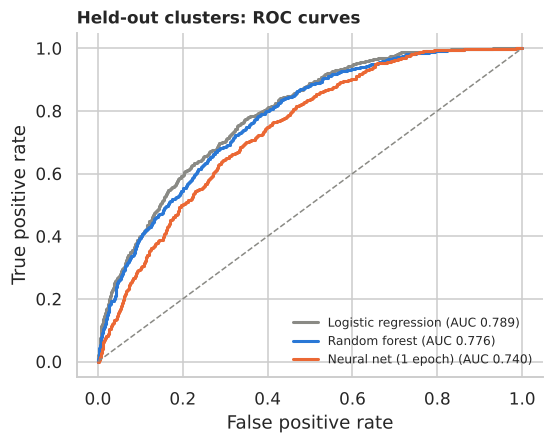

Saved outputs/results_summary.json


In [15]:
# ==========================================================================
# SECTION 14 - FINAL COMPARISON AND SAVING THE NUMBERS.
# Everything is brought together in one table and one ROC figure: logistic regression, random forest and the one-epoch neural network, all scored on the same held-out clusters with the same function. The neural network is not expected to win after a single epoch; the point of this run is the pipeline, not the leaderboard, so the comparison is shown for transparency and to set the target for the full training run. All headline numbers collected during the notebook are written to outputs/results_summary.json, which is the single source for the figures quoted in the project proposal, so the document and the code can never disagree.
# ==========================================================================
comparison = pd.DataFrame(results).set_index("model")
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(5.2, 4.2))
for name, proba, col in [("Logistic regression", p_lr, GREY), ("Random forest", p_rf, BLUE), ("Neural net (1 epoch)", p_nn, ORANGE)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} (AUC {roc_auc_score(y_test, proba):.3f})")
ax.plot([0, 1], [0, 1], "--", color=GREY, lw=1)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.set_title("Held-out clusters: ROC curves", loc="left")
ax.legend(loc="lower right", frameon=False, fontsize=8); plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig_roc.png"), dpi=200, bbox_inches="tight"); plt.show()

RESULTS["models"] = {m: {k: round(float(v), 4) for k, v in r.items()} for m, r in comparison.iterrows()}
RESULTS["splits"] = {"train": int(len(train_idx)), "val": int(len(val_idx)), "test": int(len(test_idx))}
RESULTS["hparams"] = HPARAMS
RESULTS["nn_params"] = int(model.count_params())
with open(os.path.join(OUT_DIR, "results_summary.json"), "w") as f:
    json.dump(RESULTS, f, indent=2)
print("Saved outputs/results_summary.json")

## Findings and honest limitations
*All figures below are produced by this notebook (fixed seed) and saved in `outputs/results_summary.json`.*

**What the data show (EICV7, 15,054 households).**
- Weighted by people, **27.4% are poor and 5.4% extremely poor**, matching NISR's published rates. Poverty is 31.6% in rural vs 16.7% in urban areas; Western (37.4%) and Southern (34.7%) provinces are highest, Kigali lowest (9.1%).
- Financial inclusion is broad but unequal: **88.8% of households hold an account**, rising from 80.8% in the poorest quintile to 96.0% in the richest. Poverty is 8.1% where a household has a bank account vs 33.9% where it does not (an association, not a causal effect).
- Social-protection reach is thin: any of the four programmes reaches **17.2% of extremely poor** and 14.2% of moderately poor households (non-poor: 8.6%), so about 83% of extremely poor households report no receipt in the last 12 months. Eligibility rules differ by programme, so this is a reach indicator, not proof of mis-targeting.

**What the models show.**
- Adding the consumption quintile pushes logistic-regression AUC to **0.978**, which is leakage (quintile is built from the same consumption that defines poverty). Without it, honest test AUC is **0.789** (logistic regression) and **0.776** (random forest) on clusters never seen in training.
- Financial-inclusion variables add signal beyond housing and demographics: random-forest AUC 0.757 → 0.776, logistic regression 0.768 → 0.789. The most relied-upon variables are household size, home internet, province, number of accounts and bank-account ownership.
- The neural network is a **1-epoch placeholder** (AUC 0.740); it is expected to trail the baselines until it is trained properly in the ML Pipeline course. Its job here is to prove the pipeline and TensorBoard logging work.

**Limitations.** (1) EICV7 is cross-sectional: it shows association, not causation, and cannot show poverty *dynamics* (that needs panel data). (2) Programme receipt is self-reported for the past 12 months. (3) AUC near 0.8 means the model is a screening aid, not a replacement for field verification. (4) Only a single epoch was run, by design.